# Feature Engineering — Step 3A

Build modeling-ready time series from `weekly_perishable.parquet`: dense store×category×week grids for most categories, chain-week series for bakery.


### Cell 1 — Setup

Load the weekly aggregated dataset. This is the input to all feature engineering downstream.


In [49]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("../..").resolve()
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)

weekly = pd.read_parquet(DATA_INTERIM / "weekly_perishable.parquet")
weekly = weekly.rename(columns={"n_transactions": "n_baskets", "avg_price": "avg_unit_price"})

print(f"Loaded weekly dataset: {len(weekly):,} rows")
print(f"Date range: {weekly['WEEK_START'].min().date()} to {weekly['WEEK_START'].max().date()}")
print(f"Categories: {weekly['PERISHABLE_CATEGORY'].unique()}")


Loaded weekly dataset: 50,749 rows
Date range: 2014-03-31 to 2015-12-14
Categories: ['PRODUCE' 'DAIRY' 'BAKERY' 'DELI' 'MEAT' 'SEAFOOD']


### Cell 2 — Build the dense grid (store × category × week)

Used for DAIRY, PRODUCE, MEAT, DELI, SEAFOOD. Fill in missing (store, category, week) combinations with zero sales so the time series has no gaps — required for lag/rolling features to be correct.


In [50]:
DENSE_CATEGORIES = ["DAIRY", "PRODUCE", "MEAT", "DELI", "SEAFOOD"]

dense = weekly[weekly["PERISHABLE_CATEGORY"].isin(DENSE_CATEGORIES)].copy()

# Build a complete (store, category, week) cartesian grid to fill gaps
all_stores = dense["STORE_ID"].unique()
all_weeks = pd.date_range(dense["WEEK_START"].min(), dense["WEEK_START"].max(), freq="W-MON")
all_cats = DENSE_CATEGORIES

# Cartesian product
grid = pd.MultiIndex.from_product(
    [all_stores, all_cats, all_weeks],
    names=["STORE_ID", "PERISHABLE_CATEGORY", "WEEK_START"]
).to_frame(index=False)

# Left-join the actual data into the grid
dense_full = grid.merge(
    dense[["STORE_ID", "PERISHABLE_CATEGORY", "WEEK_START", "units_sold", "sales_value", "n_baskets", "avg_unit_price", "n_unique_skus"]],
    on=["STORE_ID", "PERISHABLE_CATEGORY", "WEEK_START"],
    how="left"
)

# Fill missing values with zeros (no sales that week) — except avg_unit_price
for col in ["units_sold", "sales_value", "n_baskets", "n_unique_skus"]:
    dense_full[col] = dense_full[col].fillna(0)

# Filter to (store, category) pairs that actually have any history
# Stores that never sold any of a category should be dropped to avoid all-zero series
active_pairs = dense.groupby(["STORE_ID", "PERISHABLE_CATEGORY"]).size().reset_index()[["STORE_ID", "PERISHABLE_CATEGORY"]]
dense_full = dense_full.merge(active_pairs, on=["STORE_ID", "PERISHABLE_CATEGORY"], how="inner")

print(f"Dense grid rows: {len(dense_full):,}")
print(f"Active (store, category) series: {dense_full.groupby(['STORE_ID','PERISHABLE_CATEGORY']).ngroups:,}")
print(f"Weeks per series: {dense_full['WEEK_START'].nunique()}")
print(f"\nZero-sales weeks in dense grid: {(dense_full['units_sold'] == 0).sum():,} ({(dense_full['units_sold'] == 0).mean()*100:.1f}%)")


Dense grid rows: 136,980
Active (store, category) series: 1,522
Weeks per series: 90

Zero-sales weeks in dense grid: 92,362 (67.4%)


### Cell 3 — Build the bakery chain-week grid

Bakery is too sparse for store-level forecasting. Aggregate to chain-week. One series, ~90 data points.


In [51]:
bakery = weekly[weekly["PERISHABLE_CATEGORY"] == "BAKERY"].copy()

bakery_chain = (
    bakery.groupby("WEEK_START")
    .agg(
        units_sold=("units_sold", "sum"),
        sales_value=("sales_value", "sum"),
        n_baskets=("n_baskets", "sum"),
        n_unique_skus=("n_unique_skus", "sum"),
        n_active_stores=("STORE_ID", "nunique"),
    )
    .reset_index()
)
bakery_chain["PERISHABLE_CATEGORY"] = "BAKERY"

# Fill missing weeks if any
full_weeks = pd.date_range(bakery_chain["WEEK_START"].min(), bakery_chain["WEEK_START"].max(), freq="W-MON")
bakery_chain = bakery_chain.set_index("WEEK_START").reindex(full_weeks).reset_index()
bakery_chain = bakery_chain.rename(columns={"index": "WEEK_START"})
bakery_chain["PERISHABLE_CATEGORY"] = "BAKERY"
for col in ["units_sold", "sales_value", "n_baskets", "n_unique_skus", "n_active_stores"]:
    bakery_chain[col] = bakery_chain[col].fillna(0)

print(f"Bakery chain-week rows: {len(bakery_chain)}")
print(f"Weekly units (median): {bakery_chain['units_sold'].median():.0f}")
print(f"Weekly units (mean):   {bakery_chain['units_sold'].mean():.0f}")
print(f"\nSample:")
print(bakery_chain.head(10).to_string(index=False))


Bakery chain-week rows: 90
Weekly units (median): 195
Weekly units (mean):   194

Sample:
WEEK_START  units_sold  sales_value  n_baskets  n_unique_skus  n_active_stores PERISHABLE_CATEGORY
2014-03-31          10        18.51         10             10               10              BAKERY
2014-04-07         122       185.11         90             99               57              BAKERY
2014-04-14         166       245.67        109            126               62              BAKERY
2014-04-21         190       280.59        119            136               66              BAKERY
2014-04-28         184       244.71        111            116               63              BAKERY
2014-05-05         136       232.29        102            108               56              BAKERY
2014-05-12         176       266.16        113            123               60              BAKERY
2014-05-19         207       290.99        133            142               69              BAKERY
2014-05-26         

### Cell 4 — Audit activity levels per (store, category) series

The 67% zero-sales rate suggests many series are inactive most weeks. Compute activity rate (% of weeks with units sold) per series. We'll use this to filter to truly active forecasting candidates.

In [52]:
# Activity rate per (store, category)
activity = (
    dense_full.groupby(["STORE_ID", "PERISHABLE_CATEGORY"])
    .agg(
        total_weeks=("WEEK_START", "count"),
        active_weeks=("units_sold", lambda x: (x > 0).sum()),
        total_units=("units_sold", "sum"),
        median_units=("units_sold", "median"),
    )
    .reset_index()
)
activity["activity_rate"] = activity["active_weeks"] / activity["total_weeks"]

print(f"Total (store, category) series: {len(activity):,}")
print(f"\nActivity rate distribution:")
print(activity["activity_rate"].describe().round(3).to_string())

print(f"\nActivity rate breakdown by category:")
print(activity.groupby("PERISHABLE_CATEGORY")["activity_rate"].describe().round(3).to_string())

print(f"\nHow many series at each activity threshold:")
for thresh in [0.25, 0.50, 0.75, 0.90]:
    n = (activity["activity_rate"] >= thresh).sum()
    print(f"  activity_rate >= {thresh:.0%}: {n:,} series")

Total (store, category) series: 1,522

Activity rate distribution:
count    1522.000
mean        0.326
std         0.415
min         0.011
25%         0.011
50%         0.044
75%         0.900
max         1.000

Activity rate breakdown by category:
                     count   mean    std    min    25%    50%    75%    max
PERISHABLE_CATEGORY                                                        
DAIRY                397.0  0.309  0.420  0.011  0.011  0.033  0.967  1.000
DELI                 276.0  0.377  0.437  0.011  0.011  0.044  0.933  1.000
MEAT                 327.0  0.356  0.442  0.011  0.011  0.044  0.989  1.000
PRODUCE              374.0  0.316  0.427  0.011  0.011  0.033  0.978  1.000
SEAFOOD              148.0  0.233  0.198  0.011  0.033  0.222  0.358  0.944

How many series at each activity threshold:
  activity_rate >= 25%: 524 series
  activity_rate >= 50%: 447 series
  activity_rate >= 75%: 417 series
  activity_rate >= 90%: 386 series


### Cell 5 — Visualize activity per category

Histogram of activity rates. Bimodal distribution (clumps near 0 and near 1) means "either a store sells the category regularly or barely at all" — easy filtering. Smooth distribution means harder threshold choice.

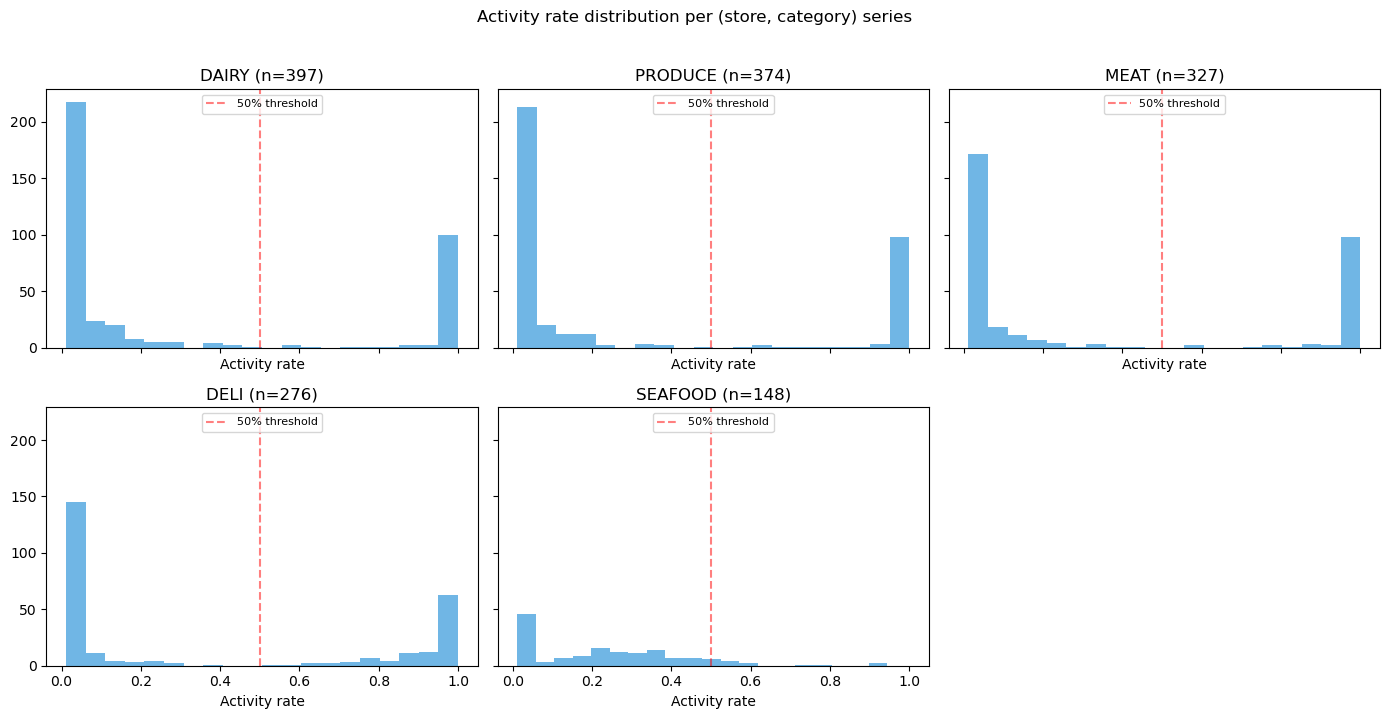

In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for ax, cat in zip(axes.flat, DENSE_CATEGORIES + ["(blank)"]):
    if cat == "(blank)":
        ax.axis("off")
        continue
    subset = activity[activity["PERISHABLE_CATEGORY"] == cat]
    ax.hist(subset["activity_rate"], bins=20, color="#3498db", alpha=0.7)
    ax.set_title(f"{cat} (n={len(subset)})")
    ax.set_xlabel("Activity rate")
    ax.axvline(0.5, color="red", linestyle="--", alpha=0.5, label="50% threshold")
    ax.legend(loc="upper center", fontsize=8)
plt.suptitle("Activity rate distribution per (store, category) series", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "activity_rate_distribution.png", dpi=100, bbox_inches="tight")
plt.show()

### Cell 6 — Filter to active (store, category) series, move SEAFOOD to chain level

Keep series with activity rate ≥ 75% for DAIRY, PRODUCE, MEAT, DELI. SEAFOOD's distribution shows no store sells it consistently, so it moves to chain-week grain like BAKERY.

In [54]:
ACTIVITY_THRESHOLD = 0.75
STORE_LEVEL_CATEGORIES = ["DAIRY", "PRODUCE", "MEAT", "DELI"]
CHAIN_LEVEL_CATEGORIES = ["BAKERY", "SEAFOOD"]

# Keep only active series for store-level categories
active_series = activity[
    (activity["PERISHABLE_CATEGORY"].isin(STORE_LEVEL_CATEGORIES)) &
    (activity["activity_rate"] >= ACTIVITY_THRESHOLD)
][["STORE_ID", "PERISHABLE_CATEGORY"]]

print(f"Active store-level series kept: {len(active_series):,}")
print(f"Breakdown by category:")
print(active_series["PERISHABLE_CATEGORY"].value_counts().to_string())

# Filter the dense grid to active series only
dense_active = dense_full.merge(active_series, on=["STORE_ID", "PERISHABLE_CATEGORY"], how="inner")

# Check the zero-sales rate now
zero_pct = (dense_active["units_sold"] == 0).mean() * 100
print(f"\nDense grid after filtering: {len(dense_active):,} rows")
print(f"Zero-sales weeks: {(dense_active['units_sold'] == 0).sum():,} ({zero_pct:.1f}%)")
print(f"(Down from {(dense_full['units_sold'] == 0).mean() * 100:.1f}% before filtering)")

Active store-level series kept: 413
Breakdown by category:
PERISHABLE_CATEGORY
DAIRY      106
MEAT       106
PRODUCE    104
DELI        97

Dense grid after filtering: 37,170 rows
Zero-sales weeks: 890 (2.4%)
(Down from 67.4% before filtering)


### Cell 7 — Build chain-week grid for BAKERY and SEAFOOD

Aggregate sparse categories to chain level. Each becomes one weekly series of ~90 data points.

In [55]:
sparse = weekly[weekly["PERISHABLE_CATEGORY"].isin(CHAIN_LEVEL_CATEGORIES)].copy()

chain_weekly = (
    sparse.groupby(["PERISHABLE_CATEGORY", "WEEK_START"])
    .agg(
        units_sold=("units_sold", "sum"),
        sales_value=("sales_value", "sum"),
        n_baskets=("n_baskets", "sum"),
        n_unique_skus=("n_unique_skus", "sum"),
        n_active_stores=("STORE_ID", "nunique"),
    )
    .reset_index()
)

# Fill any missing weeks
full_weeks = pd.date_range(chain_weekly["WEEK_START"].min(), chain_weekly["WEEK_START"].max(), freq="W-MON")

filled = []
for cat in CHAIN_LEVEL_CATEGORIES:
    sub = chain_weekly[chain_weekly["PERISHABLE_CATEGORY"] == cat].set_index("WEEK_START")
    sub = sub.reindex(full_weeks).reset_index().rename(columns={"index": "WEEK_START"})
    sub["PERISHABLE_CATEGORY"] = cat
    for col in ["units_sold", "sales_value", "n_baskets", "n_unique_skus", "n_active_stores"]:
        sub[col] = sub[col].fillna(0)
    filled.append(sub)

chain_weekly = pd.concat(filled, ignore_index=True)

print(f"Chain-weekly rows: {len(chain_weekly)}")
print(f"\nSummary per category:")
print(chain_weekly.groupby("PERISHABLE_CATEGORY").agg(
    median_units=("units_sold", "median"),
    mean_units=("units_sold", "mean"),
    weeks=("WEEK_START", "count"),
).round(0).to_string())

Chain-weekly rows: 180

Summary per category:
                     median_units  mean_units  weeks
PERISHABLE_CATEGORY                                 
BAKERY                      195.0       194.0     90
SEAFOOD                      62.0        65.0     90


### Cell 8 — Save the two modeling grids

Two files: dense store-category grid (DAIRY, PRODUCE, MEAT, DELI) and sparse chain grid (BAKERY, SEAFOOD). Feature engineering in next cells builds lags and rolling stats on each.

In [56]:
# Add time features to both grids
for df in [dense_active, chain_weekly]:
    df["YEAR"] = df["WEEK_START"].dt.year
    df["MONTH"] = df["WEEK_START"].dt.month
    df["WEEK_OF_YEAR"] = df["WEEK_START"].dt.isocalendar().week.astype(int)

dense_path = DATA_INTERIM / "dense_store_category_weekly.parquet"
chain_path = DATA_INTERIM / "chain_weekly.parquet"

dense_active.to_parquet(dense_path, index=False)
chain_weekly.to_parquet(chain_path, index=False)

print(f"Saved:")
print(f"  {dense_path.name}  ({dense_path.stat().st_size / 1e6:.2f} MB, {len(dense_active):,} rows)")
print(f"  {chain_path.name}  ({chain_path.stat().st_size / 1e3:.1f} KB, {len(chain_weekly):,} rows)")

Saved:
  dense_store_category_weekly.parquet  (0.52 MB, 37,170 rows)
  chain_weekly.parquet  (11.0 KB, 180 rows)


### Cell 9 — Build lag features (past values of units sold)

For each series, create columns: units_lag_1, units_lag_2, units_lag_4, units_lag_8, units_lag_52. All use shift(lag) within each series so they only contain data the model would have at prediction time — no future leakage.

In [57]:
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path("../..").resolve()
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"

# Load both grids
dense = pd.read_parquet(DATA_INTERIM / "dense_store_category_weekly.parquet")
chain = pd.read_parquet(DATA_INTERIM / "chain_weekly.parquet")

LAG_WEEKS = [1, 2, 4, 8, 52]

def add_lag_features(df, group_cols, target_col="units_sold", lag_weeks=LAG_WEEKS):
    """Add lag features safely. Each lag uses .shift(lag) within group."""
    df = df.sort_values(group_cols + ["WEEK_START"]).copy()
    for lag in lag_weeks:
        col_name = f"units_lag_{lag}"
        df[col_name] = df.groupby(group_cols)[target_col].shift(lag)
    return df

# Apply to both grids
dense_with_lags = add_lag_features(dense, group_cols=["STORE_ID", "PERISHABLE_CATEGORY"])
chain_with_lags = add_lag_features(chain, group_cols=["PERISHABLE_CATEGORY"])

print("Dense grid lag features:")
print(f"  Rows: {len(dense_with_lags):,}")
lag_cols = [f"units_lag_{l}" for l in LAG_WEEKS]
print(f"  Null counts (expected — early weeks have no history):")
print(dense_with_lags[lag_cols].isnull().sum().to_string())

print("\nChain grid lag features:")
print(f"  Rows: {len(chain_with_lags)}")
print(f"  Null counts:")
print(chain_with_lags[lag_cols].isnull().sum().to_string())

# Quick sanity check — show one series with its lags
sample_series = dense_with_lags[
    (dense_with_lags["STORE_ID"] == dense_with_lags["STORE_ID"].iloc[0]) &
    (dense_with_lags["PERISHABLE_CATEGORY"] == "DAIRY")
].head(10)
print(f"\nExample series (first store, DAIRY) — verify lag_1 = previous week's units:")
print(sample_series[["WEEK_START", "units_sold", "units_lag_1", "units_lag_2", "units_lag_4"]].to_string(index=False))

Dense grid lag features:
  Rows: 37,170
  Null counts (expected — early weeks have no history):
units_lag_1       413
units_lag_2       826
units_lag_4      1652
units_lag_8      3304
units_lag_52    21476

Chain grid lag features:
  Rows: 180
  Null counts:
units_lag_1       2
units_lag_2       4
units_lag_4       8
units_lag_8      16
units_lag_52    104

Example series (first store, DAIRY) — verify lag_1 = previous week's units:
WEEK_START  units_sold  units_lag_1  units_lag_2  units_lag_4
2014-03-31         0.0          NaN          NaN          NaN
2014-04-07         9.0          0.0          NaN          NaN
2014-04-14        10.0          9.0          0.0          NaN
2014-04-21        18.0         10.0          9.0          NaN
2014-04-28         6.0         18.0         10.0          0.0
2014-05-05         6.0          6.0         18.0          9.0
2014-05-12        17.0          6.0          6.0         10.0
2014-05-19        19.0         17.0          6.0         18.0
2014-0

### Cell 10 — Build rolling average and standard deviation features

For each series, compute 4-week and 12-week rolling mean and standard deviation. These capture recent trend and volatility. Same shift(1) discipline — no future leakage.

In [58]:
ROLLING_WINDOWS = [4, 12]

def add_rolling_features(df, group_cols, target_col="units_sold", windows=ROLLING_WINDOWS):
    """Add rolling mean and std features. All shifted to avoid leakage."""
    df = df.sort_values(group_cols + ["WEEK_START"]).copy()
    for window in windows:
        # Mean — shift first, then compute rolling on past data only
        shifted = df.groupby(group_cols)[target_col].shift(1)
        df[f"units_roll_mean_{window}"] = (
            shifted.groupby([df[c] for c in group_cols]).transform(lambda x: x.rolling(window, min_periods=1).mean())
        )
        df[f"units_roll_std_{window}"] = (
            shifted.groupby([df[c] for c in group_cols]).transform(lambda x: x.rolling(window, min_periods=2).std())
        )
    return df

dense_with_rolling = add_rolling_features(dense_with_lags, group_cols=["STORE_ID", "PERISHABLE_CATEGORY"])
chain_with_rolling = add_rolling_features(chain_with_lags, group_cols=["PERISHABLE_CATEGORY"])

print("Dense grid rolling features:")
roll_cols = [f"units_roll_{stat}_{w}" for stat in ["mean", "std"] for w in ROLLING_WINDOWS]
print(f"  Null counts:")
print(dense_with_rolling[roll_cols].isnull().sum().to_string())

# Sanity check
sample = dense_with_rolling[
    (dense_with_rolling["STORE_ID"] == dense_with_rolling["STORE_ID"].iloc[0]) &
    (dense_with_rolling["PERISHABLE_CATEGORY"] == "DAIRY")
].head(12)
print(f"\nExample series — verify roll_mean_4 looks like a 4-week average of past data:")
print(sample[["WEEK_START", "units_sold", "units_lag_1", "units_roll_mean_4", "units_roll_std_4"]].round(2).to_string(index=False))

Dense grid rolling features:
  Null counts:
units_roll_mean_4     413
units_roll_mean_12    413
units_roll_std_4      826
units_roll_std_12     826

Example series — verify roll_mean_4 looks like a 4-week average of past data:
WEEK_START  units_sold  units_lag_1  units_roll_mean_4  units_roll_std_4
2014-03-31         0.0          NaN                NaN               NaN
2014-04-07         9.0          0.0               0.00               NaN
2014-04-14        10.0          9.0               4.50              6.36
2014-04-21        18.0         10.0               6.33              5.51
2014-04-28         6.0         18.0               9.25              7.37
2014-05-05         6.0          6.0              10.75              5.12
2014-05-12        17.0          6.0              10.00              5.66
2014-05-19        19.0         17.0              11.75              6.65
2014-05-26         5.0         19.0              12.00              6.98
2014-06-02        10.0          5.0        

### Cell — Calendar features

Month, week-of-year, quarter, weeks-to-year-end, and weeks-to-Christmas countdown. Holiday binary flags were dropped after verification showed weak signal at this retailer.

In [59]:
import pandas as pd

# Christmas Day for each year — used for continuous countdown feature
CHRISTMAS_DATES = pd.to_datetime(["2014-12-25", "2015-12-25"])


def add_calendar_features(df):
    df = df.copy()
    df["MONTH"] = df["WEEK_START"].dt.month
    df["WEEK_OF_YEAR"] = df["WEEK_START"].dt.isocalendar().week.astype(int)
    df["QUARTER"] = df["WEEK_START"].dt.quarter

    # Weeks to year-end
    df["WEEKS_TO_YEAR_END"] = (
        (pd.to_datetime(df["YEAR"].astype(str) + "-12-31") - df["WEEK_START"]).dt.days // 7
    ).clip(lower=0)

    # Weeks to nearest upcoming Christmas, clipped to 0-12
    def weeks_to_christmas(week_start):
        future = CHRISTMAS_DATES[CHRISTMAS_DATES >= week_start]
        if len(future) == 0:
            return 12
        return min((future[0] - week_start).days // 7, 12)

    df["WEEKS_TO_CHRISTMAS"] = df["WEEK_START"].apply(weeks_to_christmas)

    return df


# Apply to both grids
dense_with_cal = add_calendar_features(dense_with_rolling)
chain_with_cal = add_calendar_features(chain_with_rolling)

print("Calendar features added (holiday verification revealed weak signal at this retailer)")
print(f"\nFinal calendar features: MONTH, WEEK_OF_YEAR, QUARTER, WEEKS_TO_YEAR_END, WEEKS_TO_CHRISTMAS")
print(f"\nWEEKS_TO_CHRISTMAS distribution:")
print(dense_with_cal["WEEKS_TO_CHRISTMAS"].value_counts().sort_index().to_string())

Calendar features added (holiday verification revealed weak signal at this retailer)

Final calendar features: MONTH, WEEK_OF_YEAR, QUARTER, WEEKS_TO_YEAR_END, WEEKS_TO_CHRISTMAS

WEEKS_TO_CHRISTMAS distribution:
WEEKS_TO_CHRISTMAS
0       413
1       826
2       826
3       826
4       826
5       826
6       826
7       826
8       826
9       826
10      826
11      826
12    27671


### Cell 12 — One-hot encode category, drop early rows with null lags, save feature tables

One-hot encode PERISHABLE_CATEGORY so the model can learn category-specific patterns. Drop rows where lag_52 is null (first 52 weeks have no year-ago comparison). Save the final modeling tables.

In [60]:
ALL_CATEGORIES = ["BAKERY", "DAIRY", "DELI", "MEAT", "PRODUCE", "SEAFOOD"]


def encode_and_finalize(df, drop_lag_nulls=True):
    df = df.copy()

    # One-hot encode for ALL categories (even those not in this grid get a column of zeros)
    # Ensures dense and chain grids have matching feature columns
    for cat in ALL_CATEGORIES:
        df[f"CAT_{cat}"] = (df["PERISHABLE_CATEGORY"] == cat).astype(int)

    if drop_lag_nulls:
        before = len(df)
        df = df.dropna(subset=["units_lag_52", "units_lag_8", "units_roll_mean_12"])
        after = len(df)
        print(f"  Dropped {before - after:,} rows with insufficient history ({(before-after)/before*100:.1f}%)")

    return df


print("Finalizing dense grid:")
dense_final = encode_and_finalize(dense_with_cal)
print(f"  Final rows: {len(dense_final):,}")
print(f"  Final columns: {dense_final.shape[1]}")

print("\nFinalizing chain grid:")
chain_final = encode_and_finalize(chain_with_cal)
print(f"  Final rows: {len(chain_final):,}")
print(f"  Final columns: {chain_final.shape[1]}")

# Save
dense_features_path = DATA_INTERIM / "features_dense.parquet"
chain_features_path = DATA_INTERIM / "features_chain.parquet"

dense_final.to_parquet(dense_features_path, index=False)
chain_final.to_parquet(chain_features_path, index=False)

print(f"\nSaved feature tables:")
print(f"  {dense_features_path.name}  ({dense_features_path.stat().st_size / 1e6:.2f} MB)")
print(f"  {chain_features_path.name}  ({chain_features_path.stat().st_size / 1e3:.1f} KB)")

print(f"\nFeature columns in dense_final:")
print(dense_final.columns.tolist())

Finalizing dense grid:
  Dropped 21,476 rows with insufficient history (57.8%)
  Final rows: 15,694
  Final columns: 29

Finalizing chain grid:
  Dropped 104 rows with insufficient history (57.8%)
  Final rows: 76
  Final columns: 28

Saved feature tables:
  features_dense.parquet  (0.61 MB)
  features_chain.parquet  (23.6 KB)

Feature columns in dense_final:
['STORE_ID', 'PERISHABLE_CATEGORY', 'WEEK_START', 'units_sold', 'sales_value', 'n_baskets', 'avg_unit_price', 'n_unique_skus', 'YEAR', 'MONTH', 'WEEK_OF_YEAR', 'units_lag_1', 'units_lag_2', 'units_lag_4', 'units_lag_8', 'units_lag_52', 'units_roll_mean_4', 'units_roll_std_4', 'units_roll_mean_12', 'units_roll_std_12', 'QUARTER', 'WEEKS_TO_YEAR_END', 'WEEKS_TO_CHRISTMAS', 'CAT_BAKERY', 'CAT_DAIRY', 'CAT_DELI', 'CAT_MEAT', 'CAT_PRODUCE', 'CAT_SEAFOOD']
